In [1]:
import sys, os
from pathlib import Path
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / 'minervachem' / '__init__.py').exists():
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

from minervachem.multi_search.optimization.utils import ParetoFront
from minervachem.multi_search.plot_utils import (
    plot_pareto_fronts, c_metric, evaluate_pareto_quality,
)
try:
    from minervachem.multi_search.plot_utils import plot_pareto_fronts_new
except ImportError:
    plot_pareto_fronts_new = plot_pareto_fronts

PAPERRUNS_SCO = 'paperruns/sco'
SCO_TARGET_SUFFIX = 'sco_kcal_octanol_gsolv_eV_octanol_hl_gap_eV_octanol_dipole'
target_names = ['sco_kcal', 'octanol_gsolv_eV', 'octanol_hl_gap_eV', 'octanol_dipole']


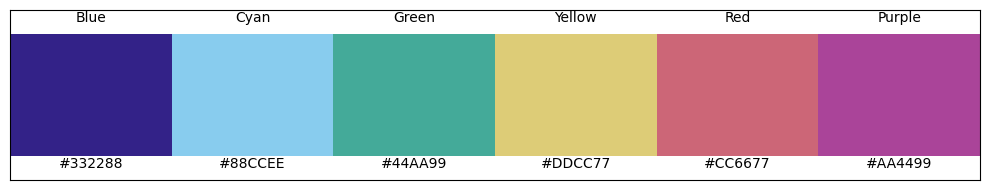

In [2]:
import matplotlib.patches as patches
palette = {
    'Blue': '#332288', 'Cyan': '#88CCEE', 'Green': '#44AA99',
    'Yellow': '#DDCC77', 'Red': '#CC6677', 'Purple': '#AA4499',
}
fig, ax = plt.subplots(figsize=(10, 2))
for i, (name, color) in enumerate(palette.items()):
    ax.add_patch(patches.Rectangle((i, 0), 1, 1, facecolor=color))
    ax.text(i + 0.5, -0.1, color, ha='center')
    ax.text(i + 0.5, 1.1, name, ha='center')
ax.set_xlim(0, len(palette)); ax.set_ylim(-0.2, 1.2)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


In [3]:
SEEDS = (3, 4)
meta_up_dfs = [
    pd.read_csv(f'{PAPERRUNS_SCO}/meta_{i}_ensemble_wupdate_{SCO_TARGET_SUFFIX}/pareto_fronts.csv')
    for i in SEEDS
]
meta_noup_dfs = [
    pd.read_csv(f'{PAPERRUNS_SCO}/meta_{i}_ensemble_woupdate_{SCO_TARGET_SUFFIX}/pareto_fronts.csv')
    for i in SEEDS
]
base_dfs = [
    pd.read_csv(f'{PAPERRUNS_SCO}/base_{i}_ensemble_wupdate_{SCO_TARGET_SUFFIX}/pareto_fronts.csv')
    for i in SEEDS
]
random_dfs = [
    pd.read_csv(f'{PAPERRUNS_SCO}/random_{i}_ensemble_{SCO_TARGET_SUFFIX}/pareto_fronts.csv')
    for i in SEEDS
]


In [4]:
grouped_dfs = {
    'meta_update':   meta_up_dfs,
    'meta_noupdate': meta_noup_dfs,
    'base':          base_dfs,
    'random':        random_dfs,
}


In [5]:
GEN_TO_CHECK = 30  # base_4 only reaches gen 30; others reach 41

def pareto_size_stats(grouped_dfs, gen=GEN_TO_CHECK, build_pf=False):
    sizes = {}
    pf_groups = {} if build_pf else None
    for alg, dfs in grouped_dfs.items():
        sizes_list, pf_list = [], []
        for df in dfs:
            sub = df[df['generation'] == gen]
            n = len(sub)
            sizes_list.append(n)
            if build_pf:
                Y = sub[target_names].to_numpy() if n else np.empty((0, len(target_names)))
                smiles = sub['SMILES'].tolist() if n else []
                pf = ParetoFront()
                pf.initialize_pareto(
                    X_list=[0.0]*len(Y) if len(Y) else [],
                    Y_list=Y if len(Y) else np.empty((0, len(target_names))),
                    smiles_list=smiles,
                )
                pf_list.append(pf)
        sizes[alg] = np.array(sizes_list, dtype=float)
        if build_pf:
            pf_groups[alg] = pf_list
        if sizes_list:
            print(f'{alg}: n_runs={len(sizes_list)} | Pareto size at gen={gen}: mean={np.mean(sizes_list):.2f}, std={np.std(sizes_list):.2f}')
    return (sizes, pf_groups) if build_pf else sizes

sizes_dict, pf_groups = pareto_size_stats(grouped_dfs, GEN_TO_CHECK, build_pf=True)
print('Sizes per algorithm at generation', GEN_TO_CHECK)
print(sizes_dict)


meta_update: n_runs=2 | Pareto size at gen=30: mean=358.50, std=20.50
meta_noupdate: n_runs=2 | Pareto size at gen=30: mean=333.50, std=4.50
base: n_runs=2 | Pareto size at gen=30: mean=263.00, std=48.00
random: n_runs=2 | Pareto size at gen=30: mean=685.00, std=8.00
Sizes per algorithm at generation 30
{'meta_update': array([338., 379.]), 'meta_noupdate': array([338., 329.]), 'base': array([215., 311.]), 'random': array([677., 693.])}


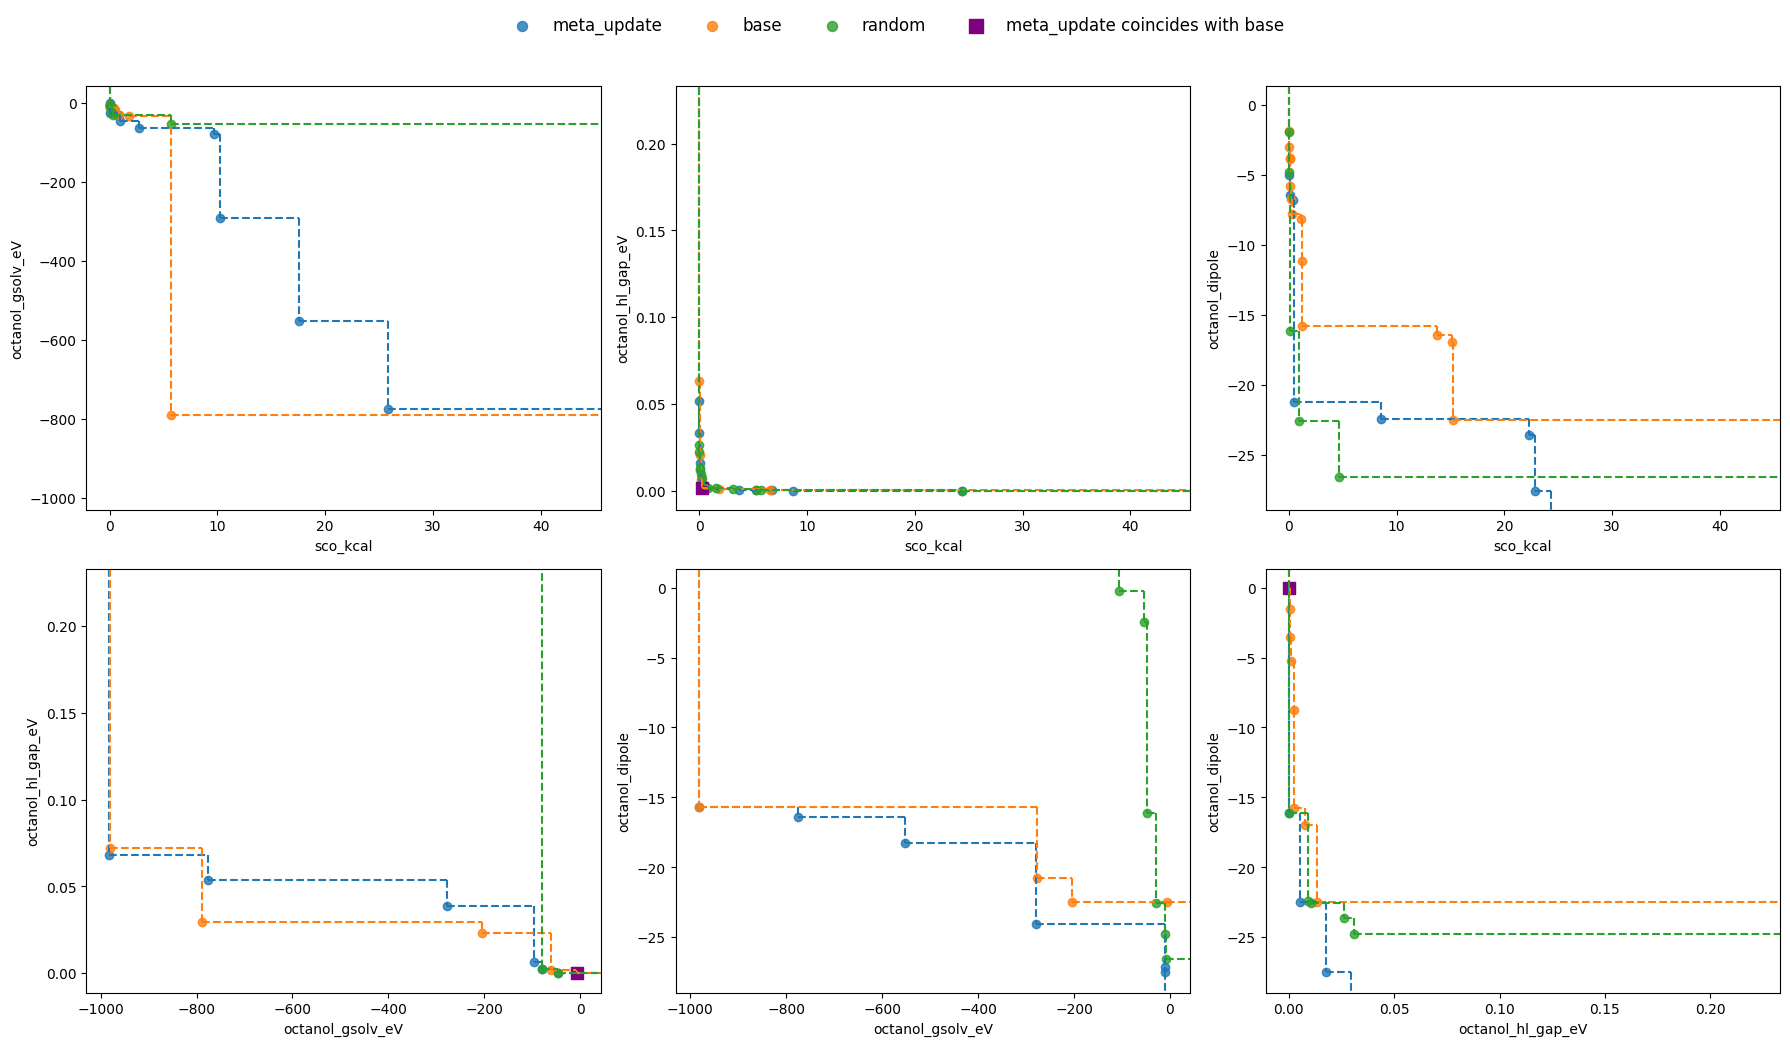

In [6]:
ensemble = 0  # SEEDS index
pf_list = [pf_groups['meta_update'][ensemble], pf_groups['base'][ensemble], pf_groups['random'][ensemble]]
exp_names = ['meta_update', 'base', 'random']
fig = plot_pareto_fronts_new(pf_list, actual_pf=None, exp_names=exp_names,
                              target_names=target_names, lim=None)


/sessions/confident-happy-curie/mnt/minervachem/minervachem/multi_search/plot_utils.py:983: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


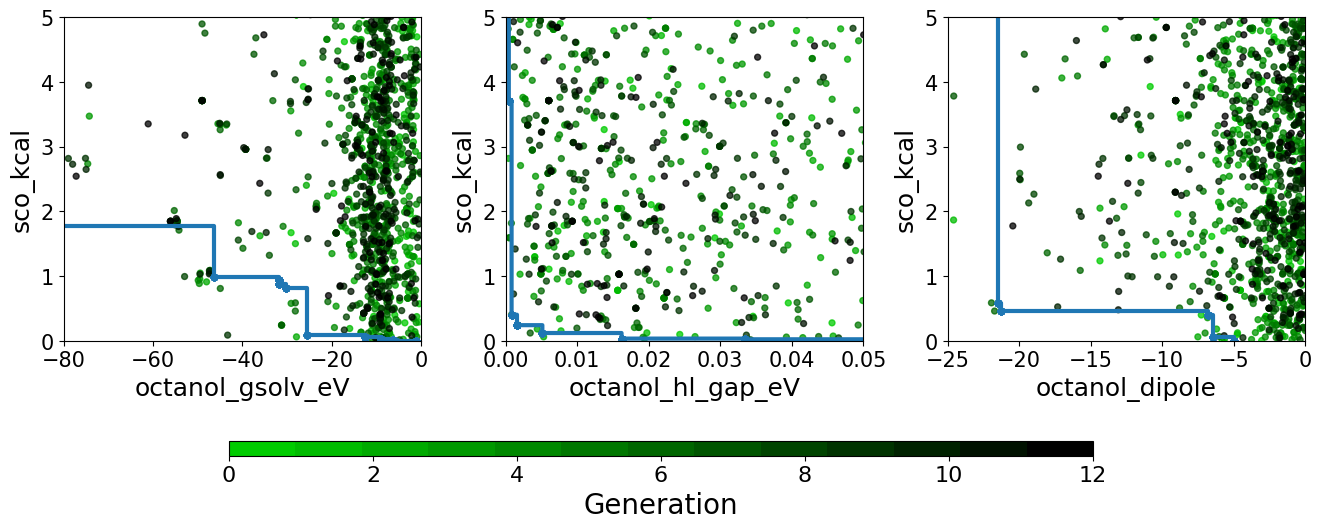

In [7]:
experiment_folder = f'{PAPERRUNS_SCO}/meta_3_ensemble_wupdate_{SCO_TARGET_SUFFIX}'
selected_indices = [0, 1, 2, 3]   # column ordering inside our pareto_fronts.csv

try:
    from minervachem.multi_search.plot_utils import plot_pareto_vs_spin_from_experiment
    fig = plot_pareto_vs_spin_from_experiment(
        experiment_folder=experiment_folder,
        selected_indices=selected_indices,
        target_names=target_names,
        spin_target_name='sco_kcal',
        query_runs_file=os.path.join(experiment_folder, 'query_runs.csv'),
        axis_limits={
            'octanol_gsolv_eV': (-80, 0),
            'sco_kcal': (0, 5),
            'octanol_hl_gap_eV': (0, 0.05),
            'octanol_dipole': (-25, 0),
        },
        highlight_points=None,
    )
except (ImportError, AttributeError) as exc:
    print(f'[skip] plot_pareto_vs_spin_from_experiment unavailable: {exc!r}')


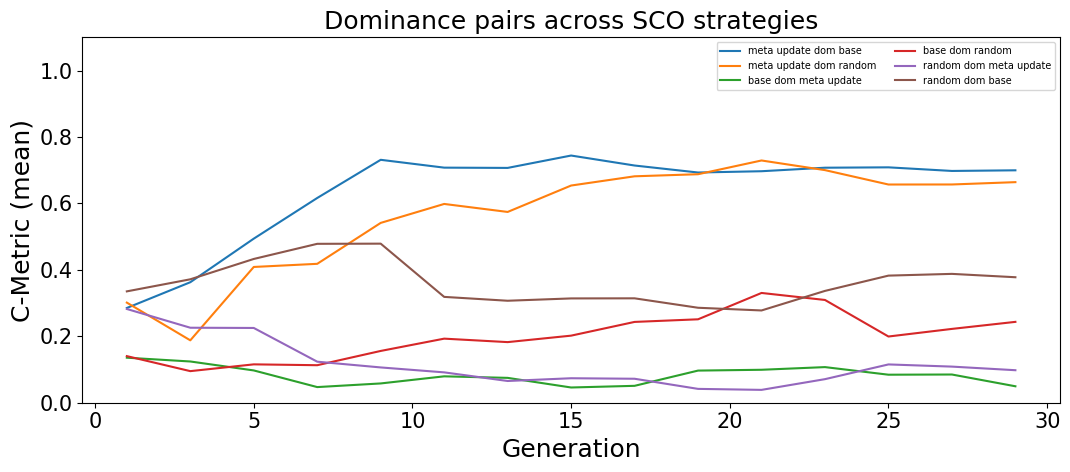

In [9]:
# C-metric on pareto-filtered fronts (raw rows are not pareto-optimal in this csv)
strategies = ['meta_update',  'base', 'random'] #'meta_noupdate',
dominance_pairs = [(a, b) for a in strategies for b in strategies if a != b]
metrics = {f'{a}_dom_{b}': [] for a, b in dominance_pairs}
generations = []

GENS_TO_PROBE = list(range(1, GEN_TO_CHECK + 1, 2))  # every 2 gens to keep it fast
for gen in GENS_TO_PROBE:
    pf_objs_per_strategy = {s: [] for s in strategies}
    for run_idx in range(len(SEEDS)):
        for s in strategies:
            df = grouped_dfs[s][run_idx]
            sub = df[df['generation'] == gen]
            if sub.empty:
                pf_objs_per_strategy[s].append(np.empty((0, 4))); continue
            Y = sub[target_names].to_numpy()
            smiles = sub['SMILES'].tolist()
            pf = ParetoFront()
            pf.initialize_pareto(X_list=[0.0]*len(Y), Y_list=Y, smiles_list=smiles)
            pf_objs_per_strategy[s].append(pf.get_objectives())
    # average per-pair across runs
    for a, b in dominance_pairs:
        vals = []
        for run_idx in range(len(SEEDS)):
            A = pf_objs_per_strategy[a][run_idx]
            B = pf_objs_per_strategy[b][run_idx]
            if A.shape[0] and B.shape[0]:
                vals.append(c_metric(A, B))
        metrics[f'{a}_dom_{b}'].append(np.mean(vals) if vals else 0.0)
    generations.append(gen)

fig, ax = plt.subplots(figsize=(11, 5))
for k, vals in metrics.items():
    if max(vals) < 0.05:
        continue
    ax.plot(generations, vals, label=k.replace('_', ' '))
ax.set_xlabel('Generation'); ax.set_ylabel('C-Metric (mean)')
ax.set_title('Dominance pairs across SCO strategies')
ax.set_ylim(0, 1.1); ax.legend(fontsize=7, ncol=2); fig.tight_layout(); plt.show()


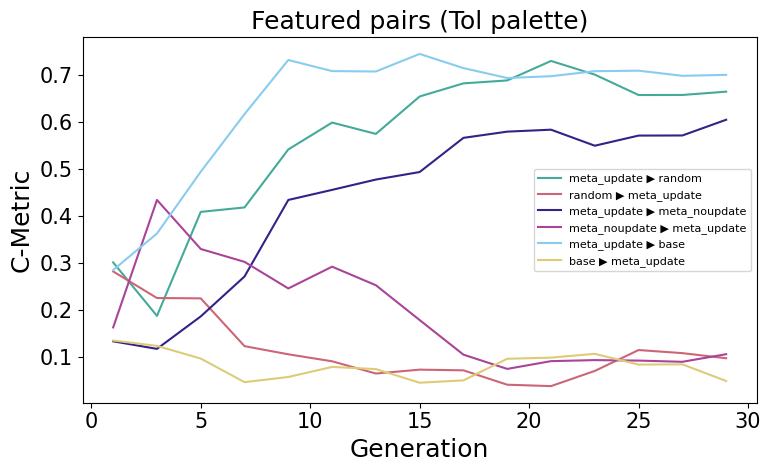

In [9]:
TOL_BLUE   = '#332288'
TOL_CYAN   = '#88CCEE'
TOL_GREEN  = '#44AA99'
TOL_YELLOW = '#DDCC77'
TOL_RED    = '#CC6677'
TOL_PURPLE = '#AA4499'

pair_color = {
    ('meta_update', 'random'):       TOL_GREEN,
    ('random', 'meta_update'):       TOL_RED,
    ('meta_update', 'meta_noupdate'): TOL_BLUE,
    ('meta_noupdate', 'meta_update'): TOL_PURPLE,
    ('meta_update', 'base'):         TOL_CYAN,
    ('base', 'meta_update'):         TOL_YELLOW,
}

fig, ax = plt.subplots(figsize=(8, 5))
for (a, b), color in pair_color.items():
    key = f'{a}_dom_{b}'
    if key in metrics:
        ax.plot(generations, metrics[key], color=color, label=f'{a} ▶ {b}')
ax.set_xlabel('Generation'); ax.set_ylabel('C-Metric')
ax.set_title('Featured pairs (Tol palette)')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## Heatmap-analysis cells (skipped)

The remaining cells in the original notebook (12 onward) drew publication-quality triangular heatmaps from `frmse_all_targets_cumulative.csv`, a derived analysis file produced by an offline post-processing step that is **not** part of the `paperruns/sco` release. They have been removed from the runnable section of the notebook. Reproduce by running the offline RMSE aggregator and re-enabling the cells.


In [13]:
import seaborn as sns
data_path = f'{PAPERRUNS_SCO}/meta_3_ensemble_wupdate_{SCO_TARGET_SUFFIX}/model_sparsity_metrics.csv'
df_sparsity = pd.read_csv(data_path)
print('rows:', len(df_sparsity), 'cols:', list(df_sparsity.columns)[:6])

# Quick smoothed plot of cosine similarity meta vs base, per target.
if {'task_name', 'cosine_meta_base'}.issubset(df_sparsity.columns):
    fig, ax = plt.subplots(figsize=(9, 4))
    for t in target_names:
        sub = df_sparsity[df_sparsity['task_name'] == t]
        if not sub.empty:
            ax.plot(sub['generation'] if 'generation' in sub else sub.index,
                    sub['cosine_meta_base'].rolling(window=5, min_periods=1).mean(),
                    label=t)
    ax.set_xlabel('Generation'); ax.set_ylabel('cos(meta, base) — smoothed')
    ax.set_title('Meta vs base cosine similarity over generations')
    ax.legend(fontsize=8); fig.tight_layout(); plt.show()
else:
    print('[skip] expected columns not present in this version of model_sparsity_metrics.csv')


rows: 133250 cols: ['train_iteration', 'target', 'bootstrap', 'cosine_meta_base', 'mean_abs_delta', 'meta_gini']
[skip] expected columns not present in this version of model_sparsity_metrics.csv
